# Modeling Intro: From Script to Library

In Notebook 01, you improved working code by making small, high-value changes.
In this notebook, you continue that same process by moving those functions into a reusable Python library.

The goal is still the same: keep behavior working while improving portability, reuse, and communication.

## Why This Matters

In scientific work, "good enough to run" is often the right starting point.
Software engineering adds lightweight improvements so the same code is easier to maintain, reuse, and share.

By the end of this notebook, you should be able to:

- Move working functions from a notebook into a Python module
- Import and run those functions from a notebook
- Use discovery tools such as `dir()` and `help()`
- Explain why this structure supports safe, portable, reproducible, robust, and literate software

## Exercise 1: Generate a Python Library

Copy the functions you built in Notebook 01 into a new Python file with a `.py` extension in this same folder.
Use a clear filename such as `barycentric_triangle.py`.

Then run the next two code cells.
They will not work until your module and function names match the imports and calls below.

Your immediate goal is to import the module, generate a triangle, and plot a point.

In [27]:
import barycentric_triangle as bt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


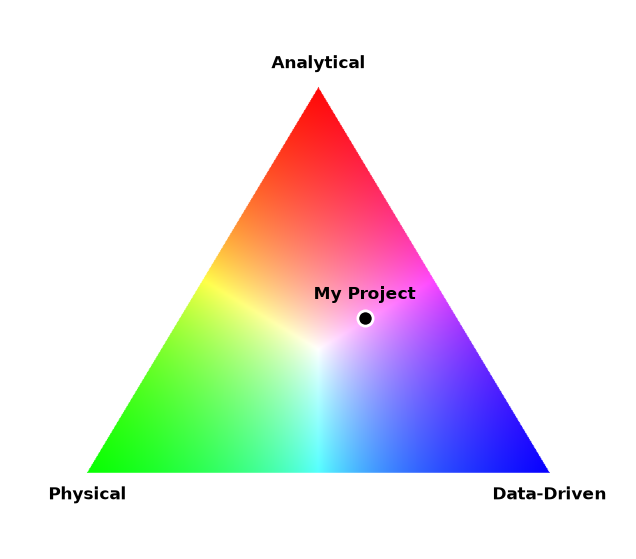

In [21]:
analytical, physical, data = bt.generate_triangle()

bt.plot_point(
    analytical,
    physical,
    data,
    analytical_weight=0.4,
    physical_weight=0.2,
    data_weight=0.4,
)

### Important Note: Developing Libraries in Jupyter

When Python successfully imports a module, it stores that module in memory. If you later edit the source file and run the import statement again, Python will usually **reuse the already-loaded version** rather than reading the file again. This can be confusing when developing your own libraries because your changes may not appear to take effect, even though you saved the file.

One solution is to restart the Jupyter kernel every time you modify the library. While this works, it quickly becomes tedious during development.

Fortunately, Jupyter provides a convenient solution. Add the following magic commands near the top of your notebook:

```python
%load_ext autoreload
%autoreload 2
```

With these enabled, Python will automatically reload imported modules whenever their source files change. This makes library development inside Jupyter notebooks much smoother.

Automatic reloading is useful during active development. In production workflows, use it more selectively.

### Team/Class Reflection

- What did you name your module file, and why?

I named my module file barycentric_triangle.py because the code here already expected it, so it was the easiest approach. It also accurately describes the purpose of the file.

- Which function names needed to be synchronized between Notebook 01 and your library?

The function names that needed to be synchronized were generate_triangle() and plot_point(). These names had to match between the library file and the functions called from Notebook 2. I could have renamed the functions here to match my old function names, but I preferred the names here. 

- What import or naming issue took the longest to debug?

The main issue I had to debug was that Jupyter was still using an older version of the imported module after I changed the function names. Using %load_ext autoreload and %autoreload 2 fixed the issue, as the notebook described. 

- How does moving code to a `.py` file improve reuse for your team?

Moving the functions into a .py file improves reuse because the same tested code can be imported into multiple notebooks or scripts without copying and pasting it. This also makes it easier for team members to share and maintain one common version of the code.

## Exercise 2: Increasing Portability

In Step 1, your code became importable.
Now focus on portability for other users: can someone discover what your library contains and how to use it without asking you?

Python provides built-in tools for this:

- `dir(module)` to see available names
- `help(function)` to inspect purpose, inputs, defaults, and expected behavior

Run the next cells and adapt naming as needed so they work with your library.

In [22]:
import barycentric_triangle

dir(barycentric_triangle)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'add_project_point',
 'generate_rgb_triangle',
 'generate_triangle',
 'is_point_inside_triangle',
 'np',
 'plot_point',
 'plot_rgb_research_triangle',
 'plt']

The `dir()` function lists names currently available in a module.
This is often the first step when exploring unfamiliar code.

Once you find an interesting function, use `help()` to inspect documentation and expected usage.

In [23]:
help(barycentric_triangle.plot_point)

Help on function plot_point in module barycentric_triangle:

plot_point(analytical_vertex, physical_vertex, data_vertex, analytical_weight=0.3333333333333333, physical_weight=0.3333333333333333, data_weight=0.3333333333333333, point_color='black', point_size=120, point_marker='o', project_label='My Project')
    Plot a research project point inside the triangle.
    
    The analytical, physical, and data-driven weights must be
    nonnegative and add up to 1.



The `help()` function displays documentation, including purpose, inputs, and expected behavior.
Clear docstrings make software more literate and easier for teammates to adopt.

Get the following help call working with your function and module names.

In [24]:
help(barycentric_triangle.plot_point)

Help on function plot_point in module barycentric_triangle:

plot_point(analytical_vertex, physical_vertex, data_vertex, analytical_weight=0.3333333333333333, physical_weight=0.3333333333333333, data_weight=0.3333333333333333, point_color='black', point_size=120, point_marker='o', project_label='My Project')
    Plot a research project point inside the triangle.
    
    The analytical, physical, and data-driven weights must be
    nonnegative and add up to 1.



At this point, you have transformed a one-off script into a reusable Python library.
This reflects a common research software path:

Experiment -> Working Script -> Reusable Functions -> Library -> Documented Tool

As you continue improving your library, remember that future users may not have your notebook, your comments, or your memory of how the code evolved.
Names, defaults, and docstrings are part of the software interface.

### Team/Class Reflection

- What did `dir()` reveal that a new user would care about?

`dir()` revealed the names available inside the `barycentric_triangle` module, including the functions `generate_triangle()` and `plot_point()`. It also showed other imported names from NumPy and Matplotlib, which makes it clear that `dir()` can include more than just the functions I created.

- What did `help()` reveal that was missing or unclear?

`help()` showed the function name, required arguments, default values, and the current docstring for `plot_point()`. The main thing that was unclear was the purpose of each individual parameter, especially the three triangle vertices and the optional plotting settings.

- Which naming or docstring change most improved discoverability?

The naming change that most improved discoverability was using `generate_triangle()` and `plot_point()` because the names directly describe what each function does. Clear names make it easier to understand the library without reading all of the source code.

- What is one small edit that would make this library easier for a classmate to use?

One small edit that would make the library easier for a classmate to use would be expanding the `plot_point()` docstring so that each parameter is described, including the expected type and meaning of the three weights. This would make the output from `help()` more informative and reduce the need to look back at the original notebook.

The next step extends this same library into a simple command-line interface so it can be used outside notebooks as well.

## Exercise 3: Turning Your Library into a Command Line Tool

So far, we have used our library from inside a Jupyter notebook.

This is a common workflow during development and exploration. However, many research software tools are eventually used outside of notebooks. One common approach is to provide a command-line interface (CLI) that allows users to run the software directly from a terminal.

In this step, you will extend your library so it can be used both:

* as a Python module imported into notebooks, and
* as a standalone command-line program.

This introduces an important Python pattern:

```python
if __name__ == "__main__":
```

This statement allows a file to behave differently depending on how it is used.

When a file is imported:

```python
from barycentric_triangle import generate_triangle
```

Python loads the functions but does not execute the code inside the if ```__name__ == "__main__"``` block.

However, when the file is run from the command line:

```bash
python barycentric_triangle.py
```

Python executes the code inside the block.

This allows one file to serve as both a reusable library and a command-line tool.

### Your Goal

Extend your library so it can:

* Generate a barycentric triangle.
* Plot one or more points.
* Save the resulting figure to a file.
* Be run directly from the command line.

For example:
```bash
python barycentric_triangle.py
```
might generate a default triangle image and a more advanced version might support arguments such as:
```bash
python barycentric_triangle.py output.png 
```
or
```bash
python barycentric_triangle.py output.png 0.5 0.3 0.2
```

### Test Your Program

Run these command-line options from the repository folder. You can also run them from a notebook cell using the `!` prefix.

In [28]:
!python barycentric_triangle.py output.png 

Figure(800x700)


In [29]:
!python barycentric_triangle.py output.png 0.5 0.3 0.2

Figure(800x700)


### Team/Class Reflection

- What advantages does a command-line interface provide?

A command-line interface allows someone to run the program directly from a terminal without opening a notebook or editing Python code. It can also make repeated or automated runs easier.

- How does a command-line tool differ from a notebook workflow?

A command-line tool differs from a notebook workflow because the user provides inputs through terminal arguments instead of editing and running individual notebook cells. Notebooks are better for exploration and visualization, while command-line tools are often better for repeatable workflows.

- Why might a researcher want both options?

A researcher may want both options because notebooks are useful during development and analysis, while a command-line interface makes the same code easier to automate, share, and run in larger workflows.

- What code belongs inside `if __name__ == "__main__":`?

The code inside `if __name__ == "__main__":` should handle things that only happen when the file is run directly, such as reading command-line arguments, choosing default values, calling the reusable functions, and saving the output file.

- What code should remain in reusable functions?

The actual scientific and plotting logic should remain inside reusable functions such as `generate_triangle()` and `plot_point()`. This keeps the core behavior available to notebooks, scripts, and other programs without automatically running the command-line workflow.